In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load dataset
data = pd.read_csv('iris (1) (1).csv')

# Features & target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Split data (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# -------- Linear Kernel --------
linear_model = svm.SVC(kernel='linear')
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))


# -------- RBF Kernel --------
rbf_model = svm.SVC(kernel='rbf')
rbf_model.fit(X_train, y_train)

y_pred_rbf = rbf_model.predict(X_test)

print("\nRBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))

Linear Kernel Accuracy: 1.0
Confusion Matrix:
 [[16  0  0]
 [ 0  7  0]
 [ 0  0  7]]

RBF Kernel Accuracy: 0.9666666666666667
Confusion Matrix:
 [[16  0  0]
 [ 0  7  0]
 [ 0  1  6]]


### SVM with Linear Kernel (IRIS Dataset)


--- Letter Recognition SVM Results ---
Accuracy Score: 0.9305
Confusion Matrix (first 10 classes for brevity):
[[144   0   1   0   0   0   1   0   0   0]
 [  0 143   0   5   0   1   0   0   0   0]
 [  0   0 123   0   2   0   3   1   0   0]
 [  0   1   0 153   0   0   0   2   0   0]
 [  0   3   1   0 130   0   5   0   0   0]
 [  0   2   0   0   1 134   0   0   1   0]
 [  1   0   1   4   0   0 149   0   0   0]
 [  0   4   0   8   0   0   0 106   0   0]
 [  0   0   0   1   0   2   0   0 134   7]
 [  0   0   0   1   1   1   0   0   3 139]]


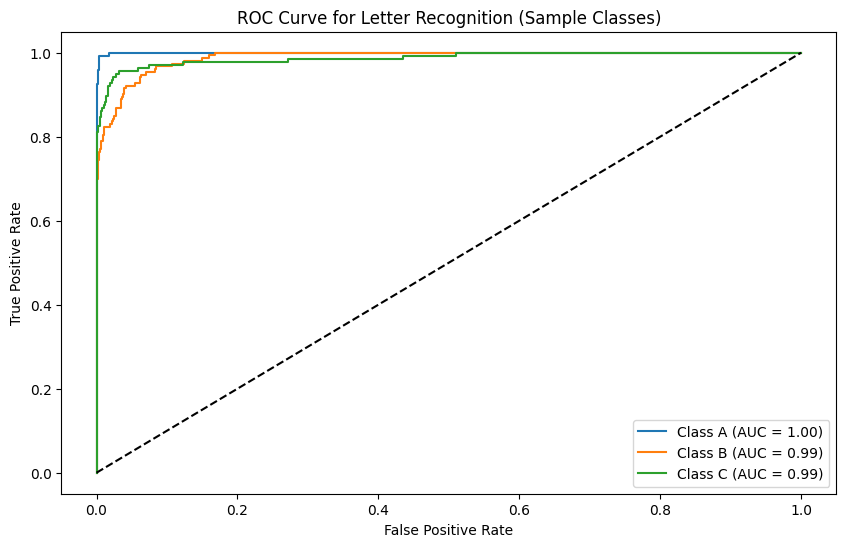

Mean AUC Score across all classes: 0.9945


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize, LabelEncoder
from sklearn.multiclass import OneVsRestClassifier

# Load dataset
letter_df = pd.read_csv('letter-recognition.csv')

# Assuming first column is the target letter, remaining 16 are features
X = letter_df.iloc[:, 1:]
y = letter_df.iloc[:, 0]

# Encode labels (A-Z -> 0-25)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_
n_classes = len(classes)

# Binarize output for ROC/AUC calculation
y_bin = label_binarize(y_encoded, classes=range(n_classes))

# Split data
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    X, y_encoded, y_bin, test_size=0.20, random_state=42
)

# 1. Standard Classifier for Accuracy and Confusion Matrix
model = SVC(kernel='rbf', probability=True)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\n--- Letter Recognition SVM Results ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("Confusion Matrix (first 10 classes for brevity):")
print(confusion_matrix(y_test, y_pred)[:10, :10])

# 2. Multi-class ROC and AUC
# We use OneVsRest wrapper to get probability scores for each class
classifier = OneVsRestClassifier(SVC(kernel='rbf', probability=True))
y_score = classifier.fit(X_train, y_train_bin).decision_function(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC curve for a few sample classes (e.g., A, B, C)
plt.figure(figsize=(10, 6))
for i in range(3): # Plotting first 3 letters for clarity
    plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Letter Recognition (Sample Classes)')
plt.legend(loc="lower right")
plt.show()

# Calculate Macro-average AUC
all_auc = list(roc_auc.values())
mean_auc = sum(all_auc) / len(all_auc)
print(f"Mean AUC Score across all classes: {mean_auc:.4f}")